# UFC Combat Capability Analyzer

Este proyecto busca desarrollar un sistema de evaluación de capacidades para peleadores de UFC utilizando estadísticas históricas.

El objetivo inicial no es predecir ganadores, sino medir y comparar habilidades en diferentes dimensiones del combate.

Categorías del modelo:

1. Striking
2. Wrestling
3. Submissions
4. Defense
5. Experience

Versiones futuras incorporarán:

- Physical Attributes
- Matchup Analysis
- Fight Prediction

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(
    r"OneDrive\Desktop\documents\Documents\Analisis Deportivo\UFC\ufc-fighters-statistics.csv"
)

In [3]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.head()

Filas: 4111
Columnas: 18


,name,nickname,wins,losses,draws,height_cm,weight_in_kg,reach_in_cm,stance,date_of_birth,significant_strikes_landed_per_minute,significant_striking_accuracy,significant_strikes_absorbed_per_minute,significant_strike_defence,average_takedowns_landed_per_15_minutes,takedown_accuracy,takedown_defense,average_submissions_attempted_per_15_minutes
0,Robert Drysdale,NaN,7,0,0,190.50,92.99,NaN,Orthodox,1981-10-05,0.00,0.0,0.00,0.0,7.32,100.0,0.0,21.9
1,Daniel McWilliams,The Animal,15,37,0,185.42,83.91,NaN,NaN,NaN,3.36,77.0,0.00,0.0,0.00,0.0,100.0,21.6
2,Dan Molina,NaN,13,9,0,177.80,97.98,NaN,NaN,NaN,0.00,0.0,5.58,60.0,0.00,0.0,0.0,20.9
3,Paul Ruiz,NaN,7,4,0,167.64,61.23,NaN,NaN,NaN,1.40,33.0,1.40,75.0,0.00,0.0,100.0,20.9
4,Collin Huckbody,All In,8,2,0,190.50,83.91,193.04,Orthodox,1994-09-29,2.05,60.0,2.73,42.0,10.23,100.0,0.0,20.4


## Selección de variables relevantes

El dataset original contiene información demográfica, física y técnica.

Para la primera versión del Combat Capability Analyzer se seleccionarán únicamente las variables relacionadas con:

- Experiencia
- Striking
- Wrestling
- Submissions
- Defense

Los atributos físicos se incorporarán en futuras versiones del modelo como una categoría independiente.

In [4]:
combat_stats = [
    "name",
    "wins",
    "losses",
    "draws",
    "significant_strikes_landed_per_minute",
    "significant_striking_accuracy",
    "significant_strike_defence",
    "average_takedowns_landed_per_15_minutes",
    "takedown_accuracy",
    "takedown_defense",
    "average_submissions_attempted_per_15_minutes"
]

fighters = df[combat_stats].copy()

fighters.head()

,name,wins,losses,draws,significant_strikes_landed_per_minute,significant_striking_accuracy,significant_strike_defence,average_takedowns_landed_per_15_minutes,takedown_accuracy,takedown_defense,average_submissions_attempted_per_15_minutes
0,Robert Drysdale,7,0,0,0.00,0.0,0.0,7.32,100.0,0.0,21.9
1,Daniel McWilliams,15,37,0,3.36,77.0,0.0,0.00,0.0,100.0,21.6
2,Dan Molina,13,9,0,0.00,0.0,60.0,0.00,0.0,0.0,20.9
3,Paul Ruiz,7,4,0,1.40,33.0,75.0,0.00,0.0,100.0,20.9
4,Collin Huckbody,8,2,0,2.05,60.0,42.0,10.23,100.0,0.0,20.4


## Construcción de variables de experiencia

El dataset original no contiene una métrica directa de experiencia.

Por ello se crearán dos variables derivadas:

- Total Fights: número total de combates registrados.
- Adjusted Win Rate: porcentaje de éxito ajustado, considerando que un empate tiene un valor intermedio entre una victoria y una derrota.

Estas variables servirán como base para la futura puntuación de Experience.

In [5]:
fighters["total_fights"] = (
    fighters["wins"] +
    fighters["losses"] +
    fighters["draws"]
)

fighters["adjusted_win_rate"] = (
    fighters["wins"] + 0.5 * fighters["draws"]
) / fighters["total_fights"]

fighters[
    ["name", "wins", "losses", "draws", "total_fights", "adjusted_win_rate"]
].head()

,name,wins,losses,draws,total_fights,adjusted_win_rate
0,Robert Drysdale,7,0,0,7,1.000000
1,Daniel McWilliams,15,37,0,52,0.288462
2,Dan Molina,13,9,0,22,0.590909
3,Paul Ruiz,7,4,0,11,0.636364
4,Collin Huckbody,8,2,0,10,0.800000


In [6]:
model_stats = [
    "significant_strikes_landed_per_minute",
    "significant_striking_accuracy",
    "significant_strike_defence",
    "average_takedowns_landed_per_15_minutes",
    "takedown_accuracy",
    "takedown_defense",
    "average_submissions_attempted_per_15_minutes",
    "total_fights",
    "adjusted_win_rate"
]

fighters[model_stats].describe()

,significant_strikes_landed_per_minute,significant_striking_accuracy,significant_strike_defence,average_takedowns_landed_per_15_minutes,takedown_accuracy,takedown_defense,average_submissions_attempted_per_15_minutes,total_fights,adjusted_win_rate
count,4111.000000,4111.000000,4111.000000,4111.000000,4111.000000,4111.000000,4111.000000,4111.000000,4092.000000
mean,2.437516,35.542447,42.643639,1.250586,26.299927,38.958891,0.610095,18.357577,0.666358
std,1.990903,20.398502,22.322427,1.935716,28.700980,34.426458,1.505924,13.519728,0.193149
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.830000,27.000000,36.000000,0.000000,0.000000,0.000000,0.000000,10.000000,0.600000
50%,2.330000,40.000000,50.000000,0.590000,22.000000,42.000000,0.000000,16.000000,0.692308
75%,3.600000,49.000000,58.000000,1.940000,45.000000,66.000000,0.700000,24.000000,0.777778
max,17.650000,100.000000,100.000000,32.140000,100.000000,100.000000,21.900000,316.000000,1.000000


# Diseño del modelo

Antes de construir las puntuaciones, se definirán las variables que compondrán cada categoría del Combat Capability Analyzer.

Categorías:

1. Striking
2. Wrestling
3. Submissions
4. Defense
5. Experience

In [7]:
model_categories = {
    "Striking": [
        "significant_strikes_landed_per_minute",
        "significant_striking_accuracy"
    ],

    "Wrestling": [
        "average_takedowns_landed_per_15_minutes",
        "takedown_accuracy"
    ],

    "Submissions": [
        "average_submissions_attempted_per_15_minutes"
    ],

    "Defense": [
        "significant_strike_defence",
        "takedown_defense"
    ],

    "Experience": [
        "total_fights",
        "adjusted_win_rate"
    ]
}

model_categories

{'Striking': ['significant_strikes_landed_per_minute',
  'significant_striking_accuracy'],
 'Wrestling': ['average_takedowns_landed_per_15_minutes', 'takedown_accuracy'],
 'Submissions': ['average_submissions_attempted_per_15_minutes'],
 'Defense': ['significant_strike_defence', 'takedown_defense'],
 'Experience': ['total_fights', 'adjusted_win_rate']}

## Normalización de métricas

Las variables utilizadas en el modelo tienen escalas diferentes.

Por ejemplo:

- Significant Strikes Landed per Minute puede tomar valores entre 0 y 17.
- Accuracy y Defense se expresan como porcentajes entre 0 y 100.
- Total Fights puede variar desde unas pocas peleas hasta varias decenas.

Antes de combinar métricas en una misma puntuación es necesario llevarlas a una escala comparable.

Para ello se utilizará normalización Min-Max.

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

## Primera categoría: Striking

La categoría Striking busca medir la capacidad ofensiva de un peleador en combate de pie.

Variables utilizadas:

- Significant Strikes Landed per Minute
- Significant Striking Accuracy

Estas métricas representan volumen y precisión de golpeo respectivamente.

In [9]:
striking_stats = [
    "significant_strikes_landed_per_minute",
    "significant_striking_accuracy"
]

fighters[striking_stats].head()

,significant_strikes_landed_per_minute,significant_striking_accuracy
0,0.00,0.0
1,3.36,77.0
2,0.00,0.0
3,1.40,33.0
4,2.05,60.0


In [10]:
fighters[striking_stats].describe()

,significant_strikes_landed_per_minute,significant_striking_accuracy
count,4111.000000,4111.000000
mean,2.437516,35.542447
std,1.990903,20.398502
min,0.000000,0.000000
25%,0.830000,27.000000
50%,2.330000,40.000000
75%,3.600000,49.000000
max,17.650000,100.000000


## Normalización de variables de Striking

Las métricas de Striking se transformarán a una escala común entre 0 y 1 utilizando Min-Max Scaling.

Esto permitirá combinar volumen y precisión de golpeo sin que una métrica domine a la otra únicamente por su escala numérica.

In [11]:
striking_normalized = pd.DataFrame(
    scaler.fit_transform(fighters[striking_stats]),
    columns=striking_stats
)

striking_normalized.head()

,significant_strikes_landed_per_minute,significant_striking_accuracy
0,0.000000,0.00
1,0.190368,0.77
2,0.000000,0.00
3,0.079320,0.33
4,0.116147,0.60


## Striking Score

El Striking Score representa la capacidad ofensiva de un peleador en combate de pie.

Se calcula utilizando:

- Significant Strikes Landed per Minute
- Significant Striking Accuracy

En la primera versión del modelo ambas variables tendrán el mismo peso.

In [12]:
striking_normalized["striking_score"] = (
    striking_normalized[
        "significant_strikes_landed_per_minute"
    ] +
    striking_normalized[
        "significant_striking_accuracy"
    ]
) / 2

striking_normalized.head()

,significant_strikes_landed_per_minute,significant_striking_accuracy,striking_score
0,0.000000,0.00,0.000000
1,0.190368,0.77,0.480184
2,0.000000,0.00,0.000000
3,0.079320,0.33,0.204660
4,0.116147,0.60,0.358074


In [13]:
fighters["striking_score"] = striking_normalized["striking_score"]

In [14]:
fighters[
    fighters["name"].isin(
        ["Ilia Topuria", "Justin Gaethje"]
    )
][[
    "name",
    "significant_strikes_landed_per_minute",
    "significant_striking_accuracy",
    "striking_score"
]]

,name,significant_strikes_landed_per_minute,significant_striking_accuracy,striking_score
472,Ilia Topuria,4.44,46.0,0.355779
3335,Justin Gaethje,7.35,60.0,0.508215


## Wrestling Score

El Wrestling Score representa la capacidad ofensiva de un peleador para llevar el combate al suelo.

Se calcula utilizando:

- Average Takedowns Landed per 15 Minutes
- Takedown Accuracy

Ambas variables tendrán el mismo peso en la primera versión del modelo.

In [15]:
wrestling_stats = [
    "average_takedowns_landed_per_15_minutes",
    "takedown_accuracy"
]

fighters[wrestling_stats].head()

,average_takedowns_landed_per_15_minutes,takedown_accuracy
0,7.32,100.0
1,0.00,0.0
2,0.00,0.0
3,0.00,0.0
4,10.23,100.0


In [16]:
fighters[wrestling_stats].describe()

,average_takedowns_landed_per_15_minutes,takedown_accuracy
count,4111.000000,4111.000000
mean,1.250586,26.299927
std,1.935716,28.700980
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.590000,22.000000
75%,1.940000,45.000000
max,32.140000,100.000000


In [17]:
wrestling_normalized = pd.DataFrame(
    scaler.fit_transform(fighters[wrestling_stats]),
    columns=wrestling_stats
)

wrestling_normalized.head()

,average_takedowns_landed_per_15_minutes,takedown_accuracy
0,0.227754,1.0
1,0.000000,0.0
2,0.000000,0.0
3,0.000000,0.0
4,0.318295,1.0


In [18]:
wrestling_normalized["wrestling_score"] = (
    wrestling_normalized[
        "average_takedowns_landed_per_15_minutes"
    ] +
    wrestling_normalized[
        "takedown_accuracy"
    ]
) / 2

wrestling_normalized.head()

,average_takedowns_landed_per_15_minutes,takedown_accuracy,wrestling_score
0,0.227754,1.0,0.613877
1,0.000000,0.0,0.000000
2,0.000000,0.0,0.000000
3,0.000000,0.0,0.000000
4,0.318295,1.0,0.659147


In [19]:
fighters["wrestling_score"] = (
    wrestling_normalized["wrestling_score"]
)

In [20]:
fighters[
    fighters["name"].isin(
        ["Ilia Topuria", "Justin Gaethje"]
    )
][[
    "name",
    "average_takedowns_landed_per_15_minutes",
    "takedown_accuracy",
    "wrestling_score"
]]

,name,average_takedowns_landed_per_15_minutes,takedown_accuracy,wrestling_score
472,Ilia Topuria,2.19,56.0,0.314070
3335,Justin Gaethje,0.13,25.0,0.127022


# 1. Data Audit

Antes de continuar con la construcción de los scores, se realizará una auditoría del dataset para comprender su estructura, calidad y posibles problemas que puedan afectar el análisis.

Se revisarán aspectos como valores faltantes, duplicados, valores extremos y diferencias en el tamaño de muestra entre peleadores.

El objetivo es identificar problemas que puedan distorsionar las métricas antes de tomar nuevas decisiones de modelado.

In [21]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

Shape: (4111, 18)

Data types:
name                                             object
nickname                                         object
wins                                              int64
losses                                            int64
draws                                             int64
height_cm                                       float64
weight_in_kg                                    float64
reach_in_cm                                     float64
stance                                           object
date_of_birth                                    object
significant_strikes_landed_per_minute           float64
significant_striking_accuracy                   float64
significant_strikes_absorbed_per_minute         float64
significant_strike_defence                      float64
average_takedowns_landed_per_15_minutes         float64
takedown_accuracy                               float64
takedown_defense                                float64
average_submissio

In [22]:
missing_values = df.isnull().sum()

missing_values

name                                               0
nickname                                        1854
wins                                               0
losses                                             0
draws                                              0
height_cm                                        298
weight_in_kg                                      87
reach_in_cm                                     1927
stance                                           823
date_of_birth                                   1135
significant_strikes_landed_per_minute              0
significant_striking_accuracy                      0
significant_strikes_absorbed_per_minute            0
significant_strike_defence                         0
average_takedowns_landed_per_15_minutes            0
takedown_accuracy                                  0
takedown_defense                                   0
average_submissions_attempted_per_15_minutes       0
dtype: int64

### Missing Values

Los valores faltantes se concentran principalmente en variables descriptivas y físicas como nickname, altura, peso, alcance, stance y fecha de nacimiento.

Las estadísticas de combate utilizadas inicialmente para construir las dimensiones de capacidad no presentan valores faltantes. Por lo tanto, los datos faltantes no impiden directamente la construcción de los scores.

Por el momento no se eliminarán observaciones. El tratamiento de los valores faltantes dependerá de si cada variable es necesaria para las siguientes etapas del análisis.

### Duplicate Records

Los registros duplicados pueden alterar las distribuciones y dar un peso desproporcionado a determinados peleadores dentro del análisis.

Se revisarán dos posibles tipos de duplicados:

- Filas completamente idénticas.
- Nombres de peleadores repetidos.

Un nombre repetido no implica necesariamente que exista un registro duplicado, por lo que estos casos deberán inspeccionarse antes de eliminar cualquier observación.

In [23]:
exact_duplicates = df.duplicated().sum()
duplicate_names = df["name"].duplicated().sum()

print("Exact duplicate rows:", exact_duplicates)
print("Repeated fighter names:", duplicate_names)

Exact duplicate rows: 0
Repeated fighter names: 6


In [24]:
repeated_names = df[
    df["name"].duplicated(keep=False)
].sort_values("name")

repeated_names

,name,nickname,wins,losses,draws,height_cm,weight_in_kg,reach_in_cm,stance,date_of_birth,significant_strikes_landed_per_minute,significant_striking_accuracy,significant_strikes_absorbed_per_minute,significant_strike_defence,average_takedowns_landed_per_15_minutes,takedown_accuracy,takedown_defense,average_submissions_attempted_per_15_minutes
1478,Bruno Silva,Bulldog,13,5,2,162.56,56.70,165.10,Orthodox,1990-03-16,3.05,46.0,3.09,59.0,2.57,30.0,64.0,0.3
2560,Bruno Silva,Blindado,23,10,0,182.88,83.91,187.96,Orthodox,1989-07-13,4.43,51.0,5.33,43.0,1.09,27.0,73.0,0.0
1829,Jean Silva,Lord Assassin,11,2,0,170.18,65.77,175.26,Orthodox,1996-12-13,5.80,48.0,4.73,55.0,1.00,33.0,100.0,0.0
3158,Jean Silva,White Bear,19,12,3,167.64,72.57,NaN,Orthodox,1977-10-08,0.73,22.0,2.93,52.0,0.00,0.0,0.0,0.0
1932,Joey Gomez,KO King,6,2,0,177.80,61.23,185.42,Orthodox,1986-07-21,2.44,28.0,4.46,55.0,0.62,100.0,50.0,0.0
2089,Joey Gomez,NaN,7,1,0,177.80,70.31,180.34,Orthodox,1989-08-29,3.73,49.0,3.33,50.0,2.00,28.0,0.0,0.0
501,Michael McDonald,Mayday,17,4,0,175.26,61.23,177.80,Orthodox,1991-01-15,2.69,42.0,2.76,57.0,1.09,66.0,52.0,1.4
2404,Michael McDonald,The Black Sniper,1,1,0,180.34,92.99,NaN,Orthodox,1965-02-06,0.00,0.0,0.40,50.0,0.00,0.0,0.0,0.0
1598,Mike Davis,Beast Boy,10,2,0,182.88,70.31,182.88,Orthodox,1992-10-07,5.83,52.0,6.20,56.0,3.04,53.0,69.0,0.2
2922,Mike Davis,NaN,2,0,0,NaN,NaN,NaN,NaN,NaN,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0


#### Duplicate Records — Hallazgo

No hay filas completamente duplicadas, aunque sí aparecen 6 nombres repetidos.

Al revisar los casos se ve que no parecen ser el mismo peleador: cambian datos como el récord, peso, fecha de nacimiento o nickname. Por eso se conservarán.

También hay que tener en cuenta que `name` no funciona como identificador único.

### Sample Size

Las estadísticas de carrera no tienen la misma confiabilidad para todos los peleadores. Un peleador con pocas peleas puede mostrar porcentajes o promedios muy altos que todavía no representan un rendimiento sostenido.

Primero se revisará cómo se distribuye el número total de peleas en el dataset.

In [25]:
df["total_fights"] = (
    df["wins"] +
    df["losses"] +
    df["draws"]
)

df["total_fights"].describe()

count    4111.000000
mean       18.357577
std        13.519728
min         0.000000
25%        10.000000
50%        16.000000
75%        24.000000
max       316.000000
Name: total_fights, dtype: float64

In [26]:
sample_size_counts = {
    "0 fights": (df["total_fights"] == 0).sum(),
    "1 fight": (df["total_fights"] == 1).sum(),
    "2 or fewer": (df["total_fights"] <= 2).sum(),
    "5 or fewer": (df["total_fights"] <= 5).sum(),
    "10 or fewer": (df["total_fights"] <= 10).sum()
}

sample_size_counts

{'0 fights': np.int64(19),
 '1 fight': np.int64(94),
 '2 or fewer': np.int64(177),
 '5 or fewer': np.int64(434),
 '10 or fewer': np.int64(1164)}

In [27]:
df.nlargest(10, "total_fights")[
    ["name", "wins", "losses", "draws", "total_fights"]
]

,name,wins,losses,draws,total_fights
3969,Travis Fulton,253,53,10,316
2134,Shannon Ritch,56,83,0,139
2420,Dan Severn,101,19,1,121
675,Jeremy Horn,91,22,5,118
349,Ikuhisa Minowa,60,42,8,110
2018,Dennis Reed,45,62,1,108
1269,Yuki Kondo,60,33,9,102
599,Travis Wiuff,75,21,0,96
3487,Keiichiro Yamamiya,45,35,10,90
3407,Shonie Carter,51,31,7,89


In [28]:
df[df["total_fights"] <= 2][
    [
        "name",
        "wins",
        "losses",
        "draws",
        "total_fights",
        "significant_strikes_landed_per_minute",
        "significant_striking_accuracy",
        "takedown_accuracy"
    ]
].head(20)

,name,wins,losses,draws,total_fights,significant_strikes_landed_per_minute,significant_striking_accuracy,takedown_accuracy
43,Eddy Millis,0,2,0,2,0.00,0.0,0.0
160,Katsuaki Furuki,1,1,0,2,0.27,10.0,0.0
164,Scott Shaffer,0,1,0,1,2.40,67.0,0.0
165,Raymond Daniels,0,1,0,1,0.00,0.0,0.0
288,Brooke Mayo,0,1,0,1,1.92,34.0,60.0
589,Joao Paulo Faria,1,1,0,2,6.69,64.0,50.0
710,Brian Schwartz,1,1,0,2,1.27,44.0,0.0
730,Jeff Crotty,1,1,0,2,0.93,35.0,38.0
1306,Danyelle Wolf,1,1,0,2,2.37,25.0,0.0
1805,Eric Schwartz,2,0,0,2,0.00,0.0,0.0


#### Sample Size — Hallazgo

El tamaño de muestra varía bastante entre peleadores. La mediana es de 16 peleas, pero 177 registros tienen 2 peleas o menos y 19 aparecen con 0 peleas.

En los peleadores con muestras pequeñas ya se observan estadísticas bastante extremas, mientras que otros tienen valores de 0 en varias métricas. Esto puede afectar los scores si se comparan directamente con peleadores que tienen carreras mucho más largas.

Por ahora no se define un mínimo de peleas. Este problema se tendrá en cuenta cuando se revise la normalización y la construcción de los scores.

### Extreme Values

Antes de decidir cómo normalizar las estadísticas, conviene revisar los valores más altos de las variables que van a formar parte del modelo.

Un valor extremo no necesariamente es un error, pero sí puede afectar bastante algunos métodos de normalización, especialmente Min-Max.

In [29]:
combat_metrics = [
    "significant_strikes_landed_per_minute",
    "significant_striking_accuracy",
    "significant_strikes_absorbed_per_minute",
    "significant_strike_defence",
    "average_takedowns_landed_per_15_minutes",
    "takedown_accuracy",
    "takedown_defense",
    "average_submissions_attempted_per_15_minutes"
]

df[combat_metrics].describe().T

,count,mean,std,min,25%,50%,75%,max
significant_strikes_landed_per_minute,4111.0,2.437516,1.990903,0.0,0.83,2.33,3.60,17.65
significant_striking_accuracy,4111.0,35.542447,20.398502,0.0,27.00,40.00,49.00,100.00
significant_strikes_absorbed_per_minute,4111.0,3.145206,2.848502,0.0,1.55,2.94,4.23,52.50
significant_strike_defence,4111.0,42.643639,22.322427,0.0,36.00,50.00,58.00,100.00
average_takedowns_landed_per_15_minutes,4111.0,1.250586,1.935716,0.0,0.00,0.59,1.94,32.14
takedown_accuracy,4111.0,26.299927,28.700980,0.0,0.00,22.00,45.00,100.00
takedown_defense,4111.0,38.958891,34.426458,0.0,0.00,42.00,66.00,100.00
average_submissions_attempted_per_15_minutes,4111.0,0.610095,1.505924,0.0,0.00,0.00,0.70,21.90


In [30]:
rate_metrics = [
    "significant_strikes_landed_per_minute",
    "significant_strikes_absorbed_per_minute",
    "average_takedowns_landed_per_15_minutes",
    "average_submissions_attempted_per_15_minutes"
]

for metric in rate_metrics:
    print(f"\nTop 5 — {metric}")
    display(
        df.nlargest(5, metric)[
            ["name", "total_fights", metric]
        ]
    )


Top 5 — significant_strikes_landed_per_minute


,name,total_fights,significant_strikes_landed_per_minute
3722,Rex Richards,9,17.65
3919,Luana Santos,7,17.10
2426,Cortavious Romious,9,14.48
2268,Danny Silva,9,13.60
3768,Angel Pacheco,9,13.13



Top 5 — significant_strikes_absorbed_per_minute


,name,total_fights,significant_strikes_absorbed_per_minute
1880,Dashawn Boatwright,4,52.50
2748,Tebaris Gordon,4,49.41
3362,Brendon Marotte,10,42.00
3967,Antonio Jones,7,30.00
3652,Tsuyoshi Tamakairiki,3,26.67



Top 5 — average_takedowns_landed_per_15_minutes


,name,total_fights,average_takedowns_landed_per_15_minutes
1794,Tom Tuggle,3,32.14
1930,Leonardo Silva de Oliveira,16,24.11
3843,Rafael Del Real,26,20.93
2445,Colley Bradford,1,19.42
2500,Michael Mangan,3,19.35



Top 5 — average_submissions_attempted_per_15_minutes


,name,total_fights,average_submissions_attempted_per_15_minutes
0,Robert Drysdale,7,21.9
1,Daniel McWilliams,52,21.6
2,Dan Molina,22,20.9
3,Paul Ruiz,11,20.9
4,Collin Huckbody,10,20.4


#### Extreme Values — Hallazgo

Las métricas basadas en tasas presentan valores bastante alejados del resto de la distribución.

En varios casos los valores más extremos aparecen en peleadores con pocas peleas, sobre todo en striking y takedowns. Sin embargo, esto no ocurre en todas las variables: submission attempts presenta valores muy altos incluso en peleadores con carreras más largas.

Esto sugiere que el tamaño de muestra explica parte del problema, pero no todos los valores extremos. También habrá que revisar si Min-Max es una buena opción para normalizar estas distribuciones.

### Suspicious Values

Además de los outliers, se revisará si existen valores que directamente no deberían ser posibles, como porcentajes mayores a 100, valores negativos o récords negativos.

In [31]:
percentage_metrics = [
    "significant_striking_accuracy",
    "significant_strike_defence",
    "takedown_accuracy",
    "takedown_defense"
]

rate_metrics = [
    "significant_strikes_landed_per_minute",
    "significant_strikes_absorbed_per_minute",
    "average_takedowns_landed_per_15_minutes",
    "average_submissions_attempted_per_15_minutes"
]

print(
    "Percentages outside 0-100:",
    ((df[percentage_metrics] < 0) | (df[percentage_metrics] > 100)).sum().sum()
)

print(
    "Negative rate values:",
    (df[rate_metrics] < 0).sum().sum()
)

print(
    "Negative record values:",
    (df[["wins", "losses", "draws"]] < 0).sum().sum()
)

Percentages outside 0-100: 0
Negative rate values: 0
Negative record values: 0


#### Suspicious Values — Hallazgo

No se encontraron porcentajes fuera del rango 0–100 ni valores negativos en las estadísticas revisadas.

Esto no descarta posibles errores o valores atípicos, pero al menos no aparecen valores directamente imposibles según estas reglas básicas.

### Distribución del tamaño de muestra

Ya vimos que el número de peleas cambia bastante entre peleadores. Ahora conviene verlo gráficamente para entender qué tan concentrada está la mayoría y cuánto influyen las carreras extremadamente largas.

**Pregunta:** ¿Cómo se distribuye el número total de peleas en el dataset?

In [32]:
import matplotlib.pyplot as plt

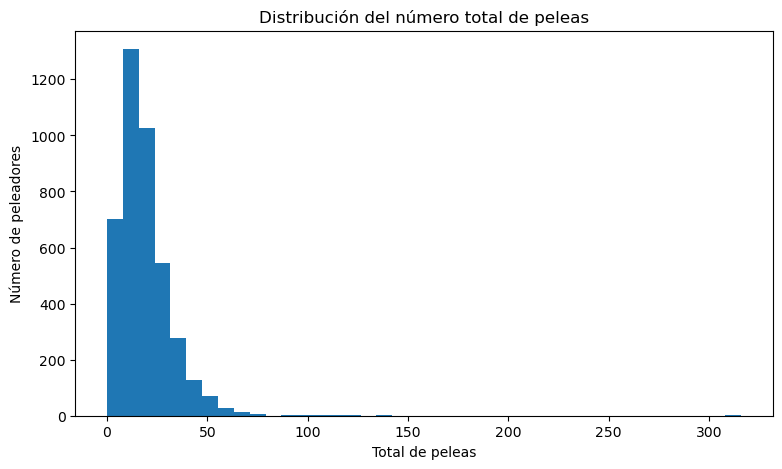

In [33]:
plt.figure(figsize=(9, 5))

plt.hist(df["total_fights"], bins=40)

plt.title("Distribución del número total de peleas")
plt.xlabel("Total de peleas")
plt.ylabel("Número de peleadores")

plt.show()

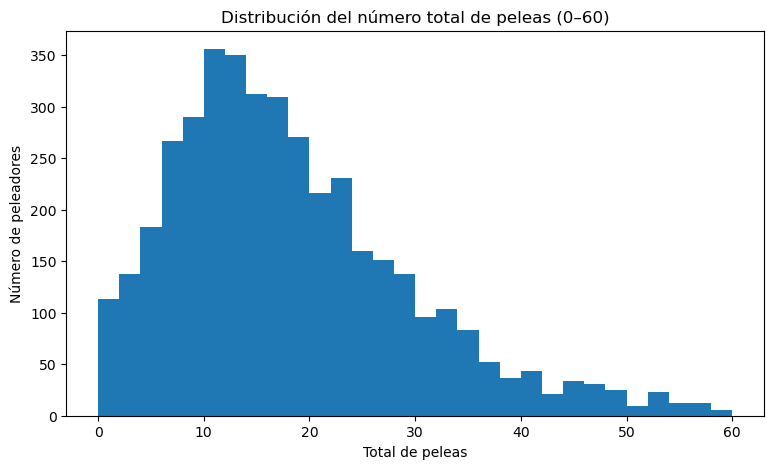

In [34]:
plt.figure(figsize=(9, 5))

plt.hist(
    df.loc[df["total_fights"] <= 60, "total_fights"],
    bins=30
)

plt.title("Distribución del número total de peleas (0–60)")
plt.xlabel("Total de peleas")
plt.ylabel("Número de peleadores")

plt.show()

#### Distribución del tamaño de muestra — Hallazgo

La distribución está sesgada hacia la derecha. La mayoría de los peleadores se concentra aproximadamente entre 5 y 30 peleas, aunque existen algunas carreras mucho más largas.

Al mostrar únicamente el rango de 0 a 60 peleas se aprecia mejor la concentración principal de los datos. Esto confirma que comparar directamente todas las estadísticas puede ser problemático, ya que no todos los peleadores tienen un historial de tamaño similar.

# 2. Exploratory Data Analysis

Después de revisar la calidad general del dataset, el siguiente paso es explorar cómo se comportan las principales estadísticas de combate y qué relaciones existen entre ellas.

El objetivo no es hacer gráficas de todas las variables, sino buscar patrones que puedan ayudarnos a tomar mejores decisiones al construir los capability scores.

## Striking

Para empezar se revisarán las dos variables que usamos inicialmente para representar striking ofensivo:

- Significant Strikes Landed per Minute
- Significant Striking Accuracy

Primero quiero ver cómo se distribuyen antes de decidir si tiene sentido normalizarlas y combinarlas de la misma forma.

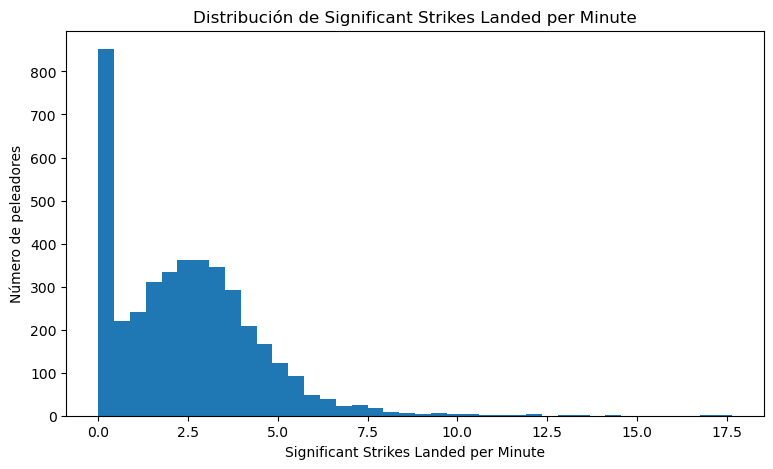

In [35]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["significant_strikes_landed_per_minute"],
    bins=40
)

plt.title("Distribución de Significant Strikes Landed per Minute")
plt.xlabel("Significant Strikes Landed per Minute")
plt.ylabel("Número de peleadores")

plt.show()

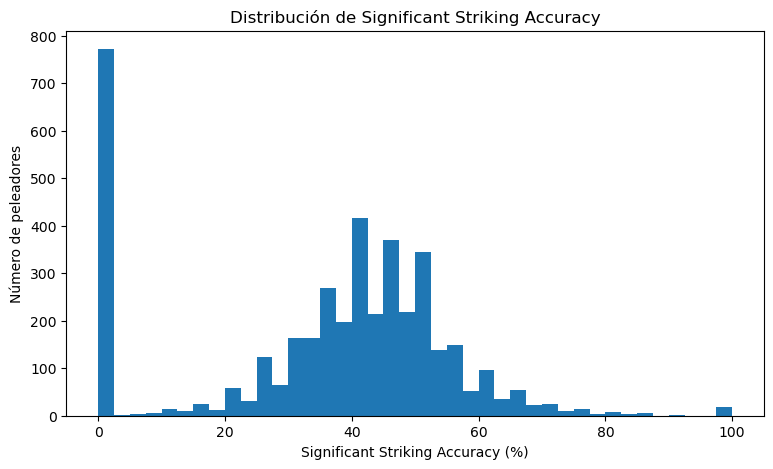

In [36]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["significant_striking_accuracy"],
    bins=40
)

plt.title("Distribución de Significant Striking Accuracy")
plt.xlabel("Significant Striking Accuracy (%)")
plt.ylabel("Número de peleadores")

plt.show()

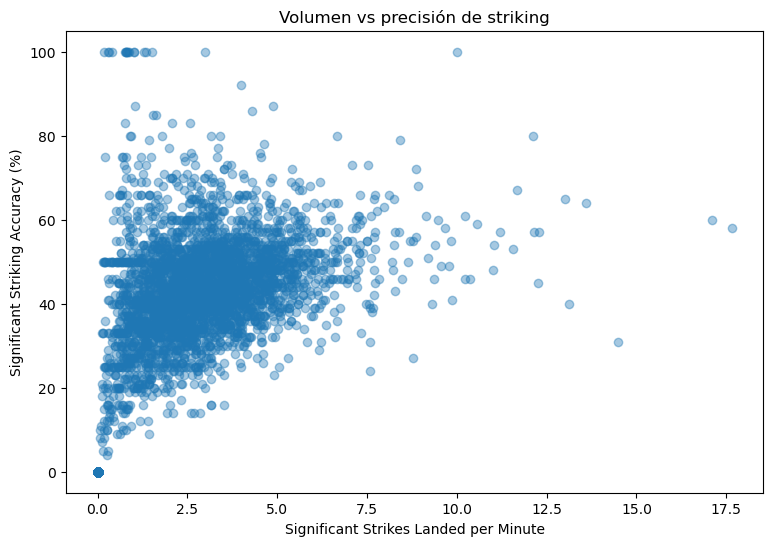

In [37]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["significant_strikes_landed_per_minute"],
    df["significant_striking_accuracy"],
    alpha=0.4
)

plt.title("Volumen vs precisión de striking")
plt.xlabel("Significant Strikes Landed per Minute")
plt.ylabel("Significant Striking Accuracy (%)")

plt.show()

In [38]:
striking_correlation = df[
    [
        "significant_strikes_landed_per_minute",
        "significant_striking_accuracy"
    ]
].corr()

striking_correlation

,significant_strikes_landed_per_minute,significant_striking_accuracy
significant_strikes_landed_per_minute,1.000000,0.628016
significant_striking_accuracy,0.628016,1.000000


#### Striking — Primeros hallazgos

SLpM y striking accuracy presentan bastantes valores en 0 y algunos extremos que se alejan del resto de la distribución.

Entre las dos variables existe una correlación positiva de aproximadamente 0.63. Esto indica que volumen y precisión están relacionados, aunque no representan exactamente lo mismo.

Por ahora se mantienen ambas variables, pero la combinación 50/50 utilizada en el primer modelo sigue siendo una decisión provisional.

## Wrestling

Para wrestling estamos utilizando dos variables:

- Average Takedowns Landed per 15 Minutes
- Takedown Accuracy

Aquí interesa revisar especialmente la cantidad de valores en 0 y si los valores extremos pueden distorsionar la comparación entre peleadores.

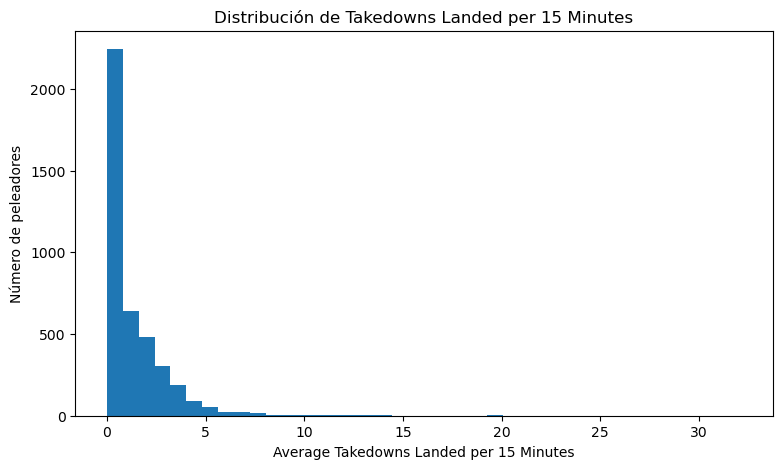

In [39]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["average_takedowns_landed_per_15_minutes"],
    bins=40
)

plt.title("Distribución de Takedowns Landed per 15 Minutes")
plt.xlabel("Average Takedowns Landed per 15 Minutes")
plt.ylabel("Número de peleadores")

plt.show()

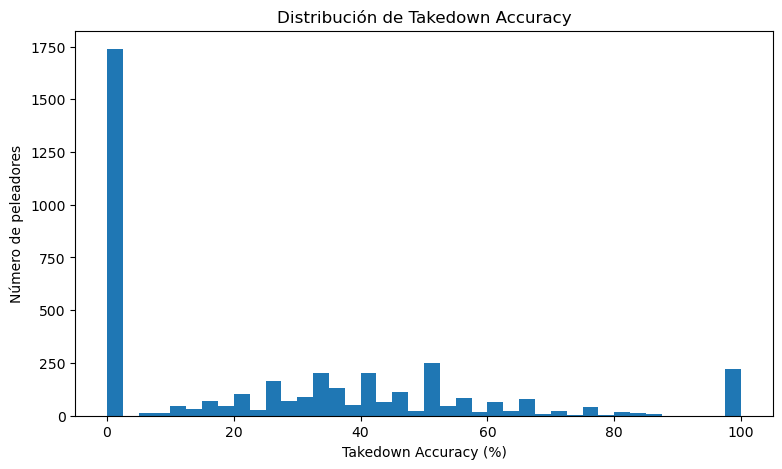

In [40]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["takedown_accuracy"],
    bins=40
)

plt.title("Distribución de Takedown Accuracy")
plt.xlabel("Takedown Accuracy (%)")
plt.ylabel("Número de peleadores")

plt.show()

In [41]:
wrestling_correlation = df[
    [
        "average_takedowns_landed_per_15_minutes",
        "takedown_accuracy"
    ]
].corr()

wrestling_correlation

,average_takedowns_landed_per_15_minutes,takedown_accuracy
average_takedowns_landed_per_15_minutes,1.000000,0.585459
takedown_accuracy,0.585459,1.000000


#### Wrestling — Primeros hallazgos

Las dos métricas de wrestling tienen una concentración importante en 0. En takedowns por 15 minutos también aparece una cola larga con algunos valores muy extremos.

Takedowns per 15 y takedown accuracy tienen una correlación positiva de aproximadamente 0.59. Están relacionadas, pero siguen midiendo aspectos diferentes.

El score 50/50 que usamos al inicio se mantiene por ahora como baseline, aunque habrá que revisar tanto los pesos como la normalización.

## Submissions

Para submissions el dataset tiene una sola variable disponible:

- Average Submissions Attempted per 15 Minutes

Esta métrica puede servir como indicador de actividad o amenaza de sumisión, pero tiene una limitación importante: intentar más sumisiones no necesariamente significa tener mayor habilidad o efectividad finalizando peleas.

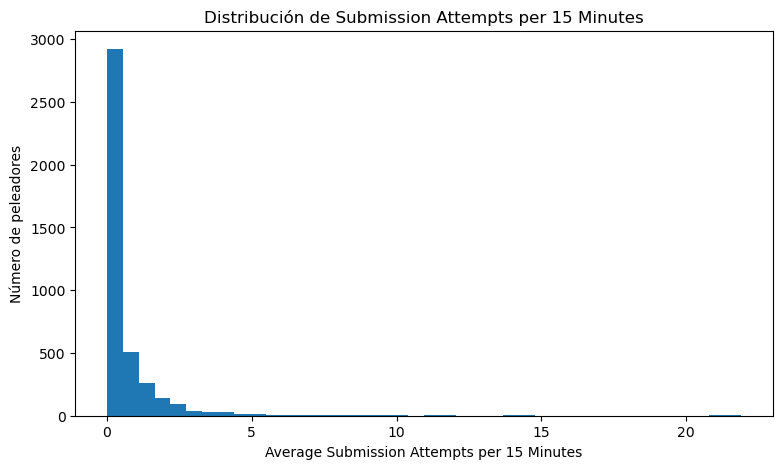

In [42]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["average_submissions_attempted_per_15_minutes"],
    bins=40
)

plt.title("Distribución de Submission Attempts per 15 Minutes")
plt.xlabel("Average Submission Attempts per 15 Minutes")
plt.ylabel("Número de peleadores")

plt.show()

In [43]:
zero_submissions = (
    df["average_submissions_attempted_per_15_minutes"] == 0
).sum()

zero_submissions_pct = (
    zero_submissions / len(df) * 100
)

print("Fighters with 0 submission attempts:", zero_submissions)
print("Percentage:", round(zero_submissions_pct, 2), "%")

Fighters with 0 submission attempts: 2321
Percentage: 56.46 %


#### Submissions — Primeros hallazgos

Submission attempts tiene una distribución muy concentrada en 0: 2,321 peleadores (56.46% del dataset) tienen un valor de 0.

Además, la variable tiene algunos valores extremos bastante alejados del resto. Esto complica usarla directamente con Min-Max

Esta métrica puede representar actividad o amenaza de sumisión, pero no mide efectividad. Por eso un futuro Submission Score tendrá que interpretarse con más cuidado que las otras dimensiones.

## Defense

Para representar defensa tenemos dos variables:

- Significant Strike Defence
- Takedown Defense

Ambas son porcentajes pero representan defensas frente a situaciones distintas. Primero vamos a revisar cómo se distribuyen y qué relación existe entre ellas.

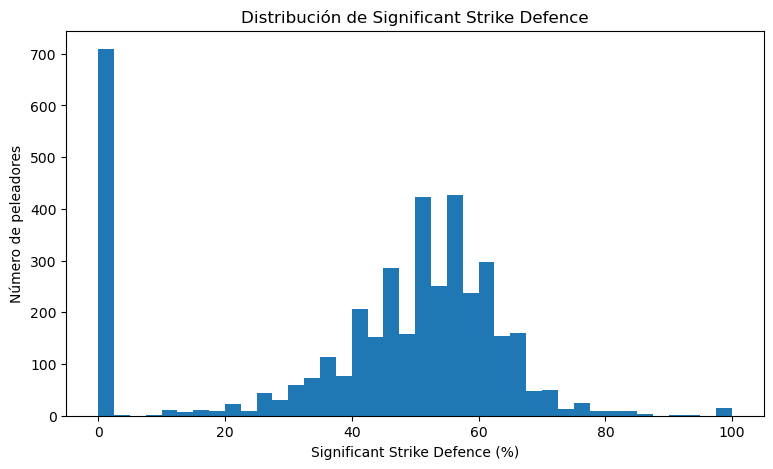

In [44]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["significant_strike_defence"],
    bins=40
)

plt.title("Distribución de Significant Strike Defence")
plt.xlabel("Significant Strike Defence (%)")
plt.ylabel("Número de peleadores")

plt.show()

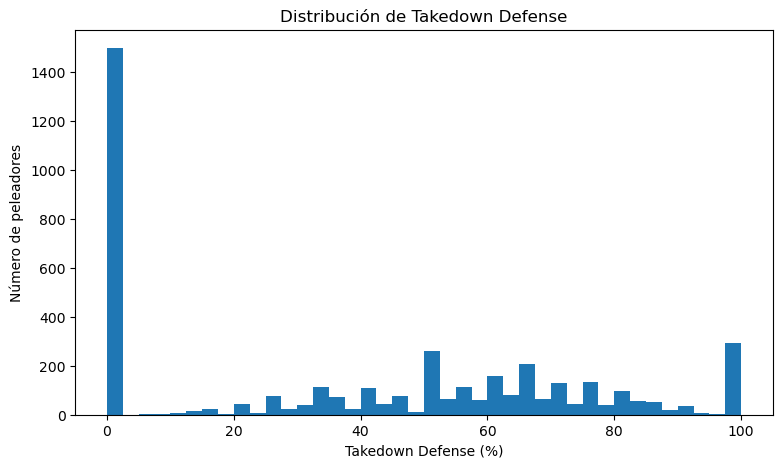

In [45]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["takedown_defense"],
    bins=40
)

plt.title("Distribución de Takedown Defense")
plt.xlabel("Takedown Defense (%)")
plt.ylabel("Número de peleadores")

plt.show()

In [46]:
defense_correlation = df[
    [
        "significant_strike_defence",
        "takedown_defense"
    ]
].corr()

defense_correlation

,significant_strike_defence,takedown_defense
significant_strike_defence,1.000000,0.526108
takedown_defense,0.526108,1.000000


#### Defense — Primeros hallazgos

Striking defense y takedown defense tienen una correlación positiva de aproximadamente 0.53. Hay cierta relación entre ambas, pero siguen capturando aspectos diferentes de la defensa.

Takedown defense también presenta muchos valores en 0 y varios en 100%, así que estos porcentajes deben interpretarse con cuidado cuando no conocemos cuántos intentos hay detrás de ellos.

Por ahora tiene sentido conservar ambas variables dentro de Defense.

## Experience

La primera versión del modelo combinaba:

- Total Fights
- Adjusted Win Rate

Pero estas variables no representan exactamente lo mismo. Total Fights mide cantidad de experiencia profesional acumulada, mientras que Adjusted Win Rate incorpora también el éxito competitivo.

Antes de mantener esta combinación, vamos a revisar cómo se comportan ambas variables y si tiene sentido tratarlas como una sola dimensión.

In [47]:
df["adjusted_win_rate"] = np.where(
    df["total_fights"] > 0,
    (df["wins"] + 0.5 * df["draws"]) / df["total_fights"],
    np.nan
)

df["adjusted_win_rate"].describe()

count    4092.000000
mean        0.666358
std         0.193149
min         0.000000
25%         0.600000
50%         0.692308
75%         0.777778
max         1.000000
Name: adjusted_win_rate, dtype: float64

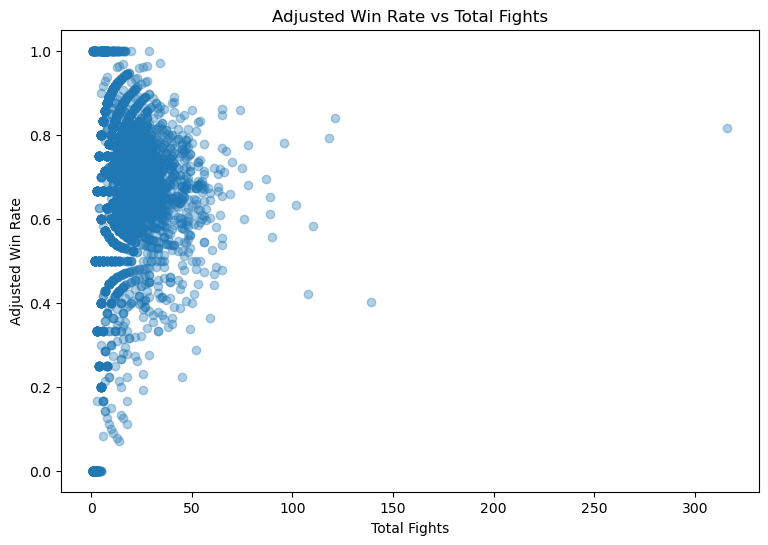

In [48]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["total_fights"],
    df["adjusted_win_rate"],
    alpha=0.35
)

plt.title("Adjusted Win Rate vs Total Fights")
plt.xlabel("Total Fights")
plt.ylabel("Adjusted Win Rate")

plt.show()

In [49]:
experience_groups = pd.cut(
    df["total_fights"],
    bins=[0, 5, 10, 20, 40, float("inf")],
    labels=["1-5", "6-10", "11-20", "21-40", "41+"]
)

df.groupby(experience_groups, observed=False)["adjusted_win_rate"].agg(
    ["count", "mean", "std"]
)

,count,mean,std
total_fights,,,
1-5,415,0.422129,0.351472
6-10,730,0.706095,0.188887
11-20,1534,0.704053,0.138029
21-40,1183,0.681640,0.112018
41+,230,0.650887,0.114704


#### Experience — Primeros hallazgos

El adjusted win rate es mucho más variable entre peleadores con pocas peleas. La desviación estándar pasa de 0.35 en carreras de 1 a 5 peleas, a valores cercanos a 0.11 cuando hay más de 20.

Esto confirma que un win rate alto con pocas peleas no tiene la misma estabilidad que uno sostenido durante una carrera más larga.

También queda una duda con la definición inicial de Experience. Total fights representa experiencia acumulada, pero adjusted win rate representa más bien rendimiento o éxito. Por eso no necesariamente deberían combinarse 50/50 solo porque ambas tienen que ver con el récord.

## Relaciones entre las variables

Antes de cerrar el EDA quiero revisar las relaciones entre las principales variables del modelo.

Esto puede ayudar a detectar métricas que estén midiendo cosas muy parecidas, relaciones entre distintas capacidades o variables que aporten información diferente.

In [50]:
eda_metrics = [
    "significant_strikes_landed_per_minute",
    "significant_striking_accuracy",
    "significant_strike_defence",
    "average_takedowns_landed_per_15_minutes",
    "takedown_accuracy",
    "takedown_defense",
    "average_submissions_attempted_per_15_minutes",
    "total_fights",
    "adjusted_win_rate"
]

correlation_matrix = df[eda_metrics].corr()

correlation_matrix.round(2)

,significant_strikes_landed_per_minute,significant_striking_accuracy,significant_strike_defence,average_takedowns_landed_per_15_minutes,takedown_accuracy,takedown_defense,average_submissions_attempted_per_15_minutes,total_fights,adjusted_win_rate
significant_strikes_landed_per_minute,1.00,0.63,0.54,0.12,0.25,0.48,-0.02,0.08,0.34
significant_striking_accuracy,0.63,1.00,0.64,0.30,0.41,0.49,0.15,0.18,0.35
significant_strike_defence,0.54,0.64,1.00,0.26,0.43,0.53,0.13,0.24,0.30
average_takedowns_landed_per_15_minutes,0.12,0.30,0.26,1.00,0.59,0.16,0.18,0.03,0.16
takedown_accuracy,0.25,0.41,0.43,0.59,1.00,0.35,0.16,0.16,0.20
takedown_defense,0.48,0.49,0.53,0.16,0.35,1.00,0.03,0.19,0.27
average_submissions_attempted_per_15_minutes,-0.02,0.15,0.13,0.18,0.16,0.03,1.00,0.06,0.06
total_fights,0.08,0.18,0.24,0.03,0.16,0.19,0.06,1.00,0.10
adjusted_win_rate,0.34,0.35,0.30,0.16,0.20,0.27,0.06,0.10,1.00


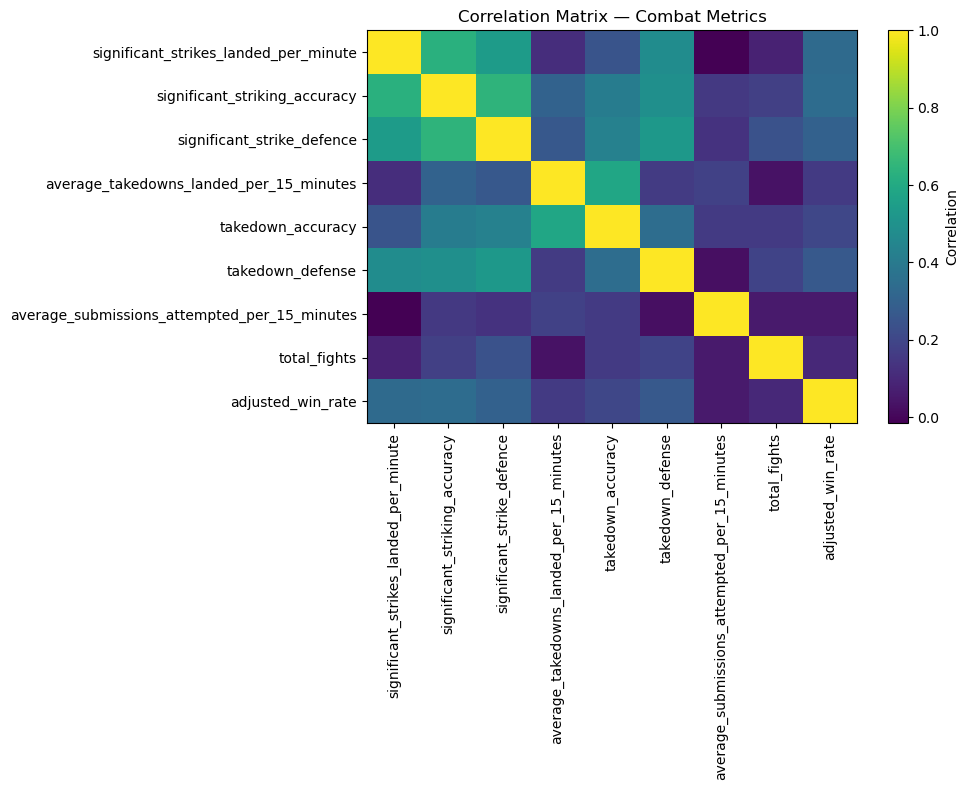

In [51]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(eda_metrics)),
    eda_metrics,
    rotation=90
)

plt.yticks(
    range(len(eda_metrics)),
    eda_metrics
)

plt.title("Correlation Matrix — Combat Metrics")

plt.tight_layout()
plt.show()

### Resumen del EDA

El análisis muestra que las métricas no tienen todas el mismo comportamiento. Algunas tienen distribuciones relativamente concentradas, mientras que takedowns y submissions presentan muchos ceros y valores extremos.

También encontramos que el tamaño de muestra importa bastante. Los peleadores con pocas peleas pueden tener porcentajes y tasas muy extremas, que no necesariamente tienen la misma confiabilidad que estadísticas sostenidas durante carreras más largas.

Las correlaciones muestran relaciones moderadas dentro de Striking, Wrestling y Defense, pero ninguna variable representa por si sola una capacidad completa. Submission attempts es además una métrica bastante diferente al resto.

Estos resultados hacen necesario revisar la normalización, el tamaño de muestra y la construcción inicial de los scores antes de definir la versión final del modelo.

# 3. Feature Engineering and Model Design

Después del EDA vamos a revisar las decisiones del modelo inicial antes de construir los scores definitivos.

Los principales problemas encontrados fueron el tamaño de muestra, los valores extremos, la gran cantidad de ceros en algunas métricas y las diferencias entre las distribuciones.

Primero se revisará el efecto del tamaño de muestra y después la forma de normalizar las variables.

## Sample reliability

Las estadísticas agregadas pueden ser menos estables cuando un peleador tiene pocas peleas.

Como el dataset no incluye el número de intentos detrás de cada porcentaje, no es posible corregir de forma precisa cada estadística. En esta primera versión prefiero no modificar los scores usando una corrección arbitraria.

En su lugar se agrega una categoría de confiabilidad basada en el número total de peleas. Esta variable no mide capacidad, solo indica cuánta información de carrera hay detrás del perfil.

In [52]:
df["sample_reliability"] = pd.cut(
    df["total_fights"],
    bins=[-1, 5, 10, 20, float("inf")],
    labels=["Very Low", "Low", "Moderate", "High"]
)

df["sample_reliability"].value_counts().sort_index()

sample_reliability
Very Low     434
Low          730
Moderate    1534
High        1413
Name: count, dtype: int64

## Revisión de la normalización

El modelo inicial utilizaba Min-Max Scaling para transformar las métricas a una escala entre 0 y 1.

El EDA mostró que algunas variables tienen distribuciones muy sesgadas y valores extremos. Esto puede hacer que Min-Max comprima demasiado a la mayoría de los peleadores.

Antes de elegir el método final voy a comparar distintas formas de normalización usando takedowns por 15 minutos como ejemplo.

In [53]:
normalization_test = df[
    ["name", "average_takedowns_landed_per_15_minutes"]
].copy()

normalization_test["minmax"] = (
    normalization_test["average_takedowns_landed_per_15_minutes"]
    - normalization_test["average_takedowns_landed_per_15_minutes"].min()
) / (
    normalization_test["average_takedowns_landed_per_15_minutes"].max()
    - normalization_test["average_takedowns_landed_per_15_minutes"].min()
)

normalization_test["percentile_rank"] = (
    normalization_test["average_takedowns_landed_per_15_minutes"]
    .rank(pct=True)
)

normalization_test.nlargest(
    20,
    "average_takedowns_landed_per_15_minutes"
)

,name,average_takedowns_landed_per_15_minutes,minmax,percentile_rank
1794,Tom Tuggle,32.14,1.000000,1.000000
1930,Leonardo Silva de Oliveira,24.11,0.750156,0.999757
3843,Rafael Del Real,20.93,0.651213,0.999514
2445,Colley Bradford,19.42,0.604231,0.999270
2500,Michael Mangan,19.35,0.602054,0.999027
3401,Mario Piazzon,18.87,0.587119,0.998784
2212,George Bush,17.31,0.538581,0.998541
4096,Eperaim Ginting,15.52,0.482887,0.998297
3329,Davi Bittencourt,14.15,0.440261,0.998054
3173,Shin Haraguchi,14.01,0.435905,0.997811


In [54]:
normalization_test[
    normalization_test["average_takedowns_landed_per_15_minutes"].between(0.5, 5)
].sample(
    20,
    random_state=42
).sort_values(
    "average_takedowns_landed_per_15_minutes"
)

,name,average_takedowns_landed_per_15_minutes,minmax,percentile_rank
1270,Jacob Kilburn,0.51,0.015868,0.485405
1262,Ciryl Gane,0.58,0.018046,0.498176
1159,Lavar Johnson,0.61,0.018979,0.502676
2191,Paul Daley,0.91,0.028314,0.565677
2247,Rama Supandhi,1.00,0.031114,0.591948
698,Jason Guida,1.00,0.031114,0.591948
3020,Mario Miranda,1.02,0.031736,0.604962
791,Stephan Bonnar,1.32,0.041070,0.655923
4065,Norma Dumont,1.39,0.043248,0.666991
1361,Rodrigo Gracie,1.49,0.046360,0.680248


In [55]:
zero_percentiles = {}

for metric in combat_metrics:
    percentile_values = df[metric].rank(pct=True)
    zero_percentiles[metric] = percentile_values[df[metric] == 0].iloc[0]

pd.Series(zero_percentiles).sort_values()

significant_strikes_absorbed_per_minute         0.085381
significant_strike_defence                      0.086354
significant_strikes_landed_per_minute           0.094016
significant_striking_accuracy                   0.094016
takedown_defense                                0.182072
average_takedowns_landed_per_15_minutes         0.211506
takedown_accuracy                               0.211506
average_submissions_attempted_per_15_minutes    0.282413
dtype: float64

In [56]:
positive_td = (
    df.loc[
        df["average_takedowns_landed_per_15_minutes"] > 0,
        "average_takedowns_landed_per_15_minutes"
    ]
)

df["td_percentile_adjusted"] = 0.0

df.loc[
    df["average_takedowns_landed_per_15_minutes"] > 0,
    "td_percentile_adjusted"
] = positive_td.rank(pct=True)

df[
    [
        "name",
        "average_takedowns_landed_per_15_minutes",
        "td_percentile_adjusted"
    ]
].sort_values(
    "average_takedowns_landed_per_15_minutes"
).head(20)

,name,average_takedowns_landed_per_15_minutes,td_percentile_adjusted
2055,Shana Olsen,0.0,0.0
3332,Kerry Schall,0.0,0.0
2090,Brad Kohler,0.0,0.0
2091,Rashad Coulter,0.0,0.0
2092,Antonio Carvalho,0.0,0.0
2094,Manuel Torres,0.0,0.0
2095,Raphael Pessoa,0.0,0.0
2088,Roshaun Jones,0.0,0.0
3328,Dariya Zheleznykova,0.0,0.0
2100,Chris Cope,0.0,0.0


In [57]:
td_positive = df[
    df["average_takedowns_landed_per_15_minutes"] > 0
].copy()

td_check = td_positive.iloc[
    np.linspace(
        0,
        len(td_positive) - 1,
        10,
        dtype=int
    )
][
    [
        "name",
        "average_takedowns_landed_per_15_minutes",
        "td_percentile_adjusted"
    ]
]

td_check.sort_values(
    "average_takedowns_landed_per_15_minutes"
)

,name,average_takedowns_landed_per_15_minutes,td_percentile_adjusted
369,Miguel Baeza,0.44,0.079435
1893,CM Punk,0.87,0.234724
658,Nate Landwehr,1.07,0.331648
2615,Cory Devela,1.07,0.331648
1545,Jesse Lennox,1.22,0.376949
3364,Alton Cunningham,1.67,0.498736
969,Reginaldo Vieira,1.97,0.576485
4110,Pauline Macias,2.00,0.595027
1257,Rafael Rebello,2.82,0.753477
0,Robert Drysdale,7.32,0.975980


#### Decisión de normalización

Min-Max resultó muy sensible a los valores extremos del dataset. En métricas como takedowns por 15 minutos, peleadores que estaban entre los valores más altos podían recibir scores bastante bajos simplemente por la presencia de unos pocos outliers.

Por eso para la V1 se utilizará percentile rank. Los valores iguales a 0 se mantienen en 0, mientras que los valores positivos se comparan solamente con el resto de valores positivos.

Así los scores representan posición relativa dentro del dataset y no distancia respecto al máximo observado.

Un score de 0.80 no significa 80% de capacidad, significa que el valor está aproximadamente en el percentil 80 dentro de la distribución utilizada.

In [58]:
def zero_adjusted_percentile(series):
    result = pd.Series(0.0, index=series.index)

    positive_mask = series > 0

    result.loc[positive_mask] = (
        series.loc[positive_mask].rank(pct=True)
    )

    return result

### Transformación de las métricas

La función anterior se aplicará a las métricas técnicas del modelo.

Se conservan las variables originales y se crean nuevas columnas normalizadas. Así podemos comparar los datos originales con las transformaciones y mantener el proceso reproducible.

In [59]:
normalized_metrics = []

for metric in combat_metrics:
    new_column = metric + "_pct"

    df[new_column] = zero_adjusted_percentile(
        df[metric]
    )

    normalized_metrics.append(new_column)

df[normalized_metrics].describe().T

,count,mean,std,min,25%,50%,75%,max
significant_strikes_landed_per_minute_pct,4111.0,0.406227,0.325367,0.0,0.076670,0.384696,0.693471,1.000000
significant_striking_accuracy_pct,4111.0,0.406227,0.325277,0.0,0.080713,0.364031,0.695268,0.997454
significant_strikes_absorbed_per_minute_pct,4111.0,0.414863,0.323310,0.0,0.095748,0.397361,0.698680,1.000000
significant_strike_defence_pct,4111.0,0.413890,0.323459,0.0,0.099206,0.397119,0.715315,0.997942
average_takedowns_landed_per_15_minutes_pct,4111.0,0.288738,0.330433,0.0,0.000000,0.133586,0.568268,1.000000
takedown_accuracy_pct,4111.0,0.288738,0.330266,0.0,0.000000,0.131479,0.572061,0.953434
takedown_defense_pct,4111.0,0.318171,0.332885,0.0,0.000000,0.209560,0.592352,0.944168
average_submissions_attempted_per_15_minutes_pct,4111.0,0.217830,0.312624,0.0,0.000000,0.000000,0.421229,1.000000


## Construcción de los Capability Scores

Los scores se construyen usando las métricas transformadas a percentile rank.

En esta primera versión se utilizarán pesos iguales cuando una dimensión tenga más de una variable. No significa que las variables tengan exactamente la misma importancia, sino que no tenemos evidencia suficiente en este dataset para justificar pesos diferentes.

Más adelante se hará un análisis de sensibilidad para revisar cuánto cambian los resultados cuando se modifican estos pesos.

In [60]:
df["striking_score"] = (
    df["significant_strikes_landed_per_minute_pct"] +
    df["significant_striking_accuracy_pct"]
) / 2

df["striking_score_100"] = (
    df["striking_score"] * 100
)

df[
    [
        "name",
        "significant_strikes_landed_per_minute",
        "significant_striking_accuracy",
        "striking_score_100",
        "sample_reliability"
    ]
].nlargest(
    15,
    "striking_score_100"
)

,name,significant_strikes_landed_per_minute,significant_striking_accuracy,striking_score_100,sample_reliability
3236,Waachiim Spiritwolf,10.00,100.0,99.588200,High
2173,Kim Couture,12.12,80.0,99.415993,Moderate
15,Kenny Ento,8.41,79.0,98.899371,High
2313,Ibo Aslan,8.87,72.0,98.592393,Moderate
2221,Ramazan Kuramagomedov,11.67,67.0,98.210542,Low
3887,Shara Magomedov,7.53,73.0,98.165618,Moderate
2943,Eli Aronov,8.92,68.0,98.015873,Low
3584,Justin Gonzales,6.67,80.0,97.911051,Low
2562,Rizvan Kuniev,7.09,73.0,97.821204,Moderate
3091,Charalampos Grigoriou,13.00,65.0,97.663971,Moderate


### Wrestling Score

Wrestling combina dos partes de la ofensiva de derribos: frecuencia de takedowns y precisión.

Para esta primera versión ambas métricas tendrán el mismo peso. Igual que en Striking, esto funciona como un baseline y no como una afirmación de que las dos tengan exactamente la misma importancia.

In [61]:
df["wrestling_score"] = (
    df["average_takedowns_landed_per_15_minutes_pct"] +
    df["takedown_accuracy_pct"]
) / 2

df["wrestling_score_100"] = (
    df["wrestling_score"] * 100
)

df[
    [
        "name",
        "average_takedowns_landed_per_15_minutes",
        "takedown_accuracy",
        "wrestling_score_100",
        "sample_reliability"
    ]
].nlargest(
    15,
    "wrestling_score_100"
)

,name,average_takedowns_landed_per_15_minutes,takedown_accuracy,wrestling_score_100,sample_reliability
1794,Tom Tuggle,32.14,100.0,97.671724,Very Low
3843,Rafael Del Real,20.93,100.0,97.629583,High
4096,Eperaim Ginting,15.52,100.0,97.524231,Low
2896,Jae Suk Lim,12.16,100.0,97.366203,High
2943,Eli Aronov,12.16,100.0,97.366203,Low
2165,Lucas Stark,12.00,100.0,97.334598,Low
2672,Greg Scott,11.69,100.0,97.302992,Low
3132,Nursulton Ruziboev,11.69,100.0,97.302992,High
16,AJ McKee,11.01,100.0,97.166035,Low
4,Collin Huckbody,10.23,100.0,97.134429,Low


### Submissions Score

Esta dimensión tiene una limitación mayor que las anteriores porque el dataset solo incluye submission attempts por 15 minutos.

Por eso este score representa mejor la actividad o amenaza de sumisión observada, no necesariamente habilidad completa ni efectividad finalizando peleas.

Además, más de la mitad de los peleadores tienen un valor de 0, algo que hay que tener presente al interpretar los resultados.

In [62]:
df["submissions_score"] = (
    df["average_submissions_attempted_per_15_minutes_pct"]
)

df["submissions_score_100"] = (
    df["submissions_score"] * 100
)

df[
    [
        "name",
        "average_submissions_attempted_per_15_minutes",
        "submissions_score_100",
        "sample_reliability"
    ]
].nlargest(
    15,
    "submissions_score_100"
)

,name,average_submissions_attempted_per_15_minutes,submissions_score_100,sample_reliability
0,Robert Drysdale,21.9,100.000000,Low
1,Daniel McWilliams,21.6,99.944134,High
2,Dan Molina,20.9,99.860335,High
3,Paul Ruiz,20.9,99.860335,Moderate
4,Collin Huckbody,20.4,99.776536,Low
5,Gerald Strebendt,16.4,99.720670,Moderate
6,Isaiah Hill,14.5,99.664804,Moderate
7,Kenneth Seegrist,14.4,99.608939,Moderate
8,Will Kerr,14.3,99.525140,Moderate
9,Neil Grove,14.3,99.525140,High


### Defense Score

Defense combina defensa de golpes significativos y defensa de takedowns.

Las dos variables están relacionadas, pero representan situaciones diferentes del combate. Para la V1 se mantienen con el mismo peso, como baseline.

Hay que tener cuidado con porcentajes extremos, sobre todo cuando vienen de carreras con pocas peleas.

In [63]:
df["defense_score"] = (
    df["significant_strike_defence_pct"] +
    df["takedown_defense_pct"]
) / 2

df["defense_score_100"] = (
    df["defense_score"] * 100
)

df[
    [
        "name",
        "significant_strike_defence",
        "takedown_defense",
        "defense_score_100",
        "sample_reliability"
    ]
].nlargest(
    15,
    "defense_score_100"
)

,name,significant_strike_defence,takedown_defense,defense_score_100,sample_reliability
191,Jeff Bedard,100.0,100.0,97.105532,Moderate
390,Casey Olson,100.0,100.0,97.105532,Moderate
2347,Sarah D'alelio,100.0,100.0,97.105532,Moderate
3121,Bobby Sanchez,100.0,100.0,97.105532,High
10,Raphael Butler,91.0,100.0,96.958560,Moderate
2129,Jacqueline Cavalcanti,84.0,100.0,96.870377,Low
2185,Brendan Seguin,84.0,100.0,96.870377,High
16,AJ McKee,80.0,100.0,96.671964,Low
2516,Gabriel Carrasco,80.0,100.0,96.671964,Low
2762,Adlan Amagov,78.0,100.0,96.532340,Moderate


### Experience Score

La versión inicial combinaba total fights y adjusted win rate, pero el EDA mostró que representan conceptos diferentes.

Total fights mide experiencia acumulada, mientras que adjusted win rate está más relacionado con rendimiento o éxito competitivo. Por eso en esta V1 no se combinarán.

Experience se construirá solamente a partir del número total de peleas. El win rate se conserva como una variable descriptiva, pero no forma parte de este score.

In [64]:
df["experience_score"] = (
    df["total_fights"].rank(
        pct=True,
        method="average"
    )
)

df.loc[
    df["total_fights"] == 0,
    "experience_score"
] = 0

df["experience_score_100"] = (
    df["experience_score"] * 100
)

df[
    [
        "name",
        "wins",
        "losses",
        "draws",
        "total_fights",
        "adjusted_win_rate",
        "experience_score_100"
    ]
].nlargest(
    15,
    "experience_score_100"
)

,name,wins,losses,draws,total_fights,adjusted_win_rate,experience_score_100
3969,Travis Fulton,253,53,10,316,0.816456,100.000000
2134,Shannon Ritch,56,83,0,139,0.402878,99.975675
2420,Dan Severn,101,19,1,121,0.838843,99.951350
675,Jeremy Horn,91,22,5,118,0.792373,99.927025
349,Ikuhisa Minowa,60,42,8,110,0.581818,99.902700
2018,Dennis Reed,45,62,1,108,0.421296,99.878375
1269,Yuki Kondo,60,33,9,102,0.632353,99.854050
599,Travis Wiuff,75,21,0,96,0.781250,99.829725
3487,Keiichiro Yamamiya,45,35,10,90,0.555556,99.805400
3407,Shonie Carter,51,31,7,89,0.612360,99.768913


## Combat Capability Profiles

Con las cinco dimensiones construidas ya podemos generar un perfil completo para cada peleador.

Los scores están expresados de 0 a 100 para facilitar su lectura. Representan posiciones relativas dentro de este dataset, no porcentajes absolutos de habilidad.

También se conserva sample reliability para tener contexto sobre la cantidad de información disponible para cada peleador.

In [65]:
profile_fighters = [
    "Ilia Topuria",
    "Justin Gaethje",
    "Jon Jones",
    "Islam Makhachev",
    "Charles Oliveira",
    "Max Holloway",
    "Tom Aspinall"
]

fighter_profiles = df[
    df["name"].isin(profile_fighters)
][
    [
        "name",
        "striking_score_100",
        "wrestling_score_100",
        "submissions_score_100",
        "defense_score_100",
        "experience_score_100",
        "sample_reliability"
    ]
].copy()

fighter_profiles[
    [
        "striking_score_100",
        "wrestling_score_100",
        "submissions_score_100",
        "defense_score_100",
        "experience_score_100"
    ]
] = fighter_profiles[
    [
        "striking_score_100",
        "wrestling_score_100",
        "submissions_score_100",
        "defense_score_100",
        "experience_score_100"
    ]
].round(1)

fighter_profiles

,name,striking_score_100,wrestling_score_100,submissions_score_100,defense_score_100,experience_score_100,sample_reliability
188,Charles Oliveira,75.1,56.7,89.6,42.0,95.2,High
397,Tom Aspinall,97.3,89.8,77.4,93.5,54.7,Moderate
472,Ilia Topuria,70.8,70.4,73.9,91.1,43.3,Moderate
762,Islam Makhachev,66.7,80.4,58.5,84.4,78.7,High
1290,Jon Jones,84.9,56.9,29.6,88.8,82.3,High
1529,Max Holloway,79.9,38.0,14.8,79.6,87.8,High
3335,Justin Gaethje,94.9,8.8,0.0,62.4,84.0,High


# 4. Validation and Sanity Checks

Antes de interpretar los perfiles finales es necesario revisar cómo se comportan los scores.

La idea no es comprobar que el modelo coincida con lo que esperamos de ciertos peleadores, sino buscar resultados raros, efectos de las transformaciones y decisiones que puedan estar dominando los resultados.

In [66]:
capability_scores = [
    "striking_score_100",
    "wrestling_score_100",
    "submissions_score_100",
    "defense_score_100",
    "experience_score_100"
]

df[capability_scores].describe().T

,count,mean,std,min,25%,50%,75%,max
striking_score_100,4111.0,40.622720,28.985038,0.0,13.065289,43.808026,63.974993,99.588200
wrestling_score_100,4111.0,28.873753,30.545874,0.0,0.000000,20.701643,54.877792,97.671724
submissions_score_100,4111.0,21.783021,31.262410,0.0,0.000000,0.000000,42.122905,100.000000
defense_score_100,4111.0,36.603016,27.620355,0.0,9.384186,37.782934,58.537875,97.105532
experience_score_100,4111.0,50.011038,28.859304,0.0,26.222330,50.972999,75.079056,100.000000


### Sample size y scores extremos

Una de las principales preocupaciones del modelo es que estadísticas muy altas pueden provenir de carreras con pocas peleas.

Para revisar este efecto voy a comparar los scores promedio entre los distintos niveles de sample reliability. Esto no demuestra por sí solo que exista sesgo, pero ayuda a detectar si los perfiles con menos información se comportan de forma diferente.

In [67]:
reliability_score_summary = (
    df.groupby(
        "sample_reliability",
        observed=True
    )[capability_scores]
    .agg(["mean", "median"])
    .round(1)
)

reliability_score_summary

striking_score_100        wrestling_score_100         \
                                 mean median                mean median   
sample_reliability                                                        
Very Low                         14.6    0.0                 9.5    0.0   
Low                              39.4   41.3                25.6    0.0   
Moderate                         44.7   47.7                30.7   24.3   
High                             44.8   47.0                34.6   36.2   

                   submissions_score_100        defense_score_100         \
                                    mean median              mean median   
sample_reliability                                                         
Very Low                             7.2    0.0              12.4    0.0   
Low                                 15.7    0.0              30.4   25.7   
Moderate                            23.1    0.0              38.5   39.6   
High                                28.0   14.8              45.2   47.7   

                   experience_score_100         
                                   mean median  
sample_reliability                              
Very Low                            5.3    5.2  
Low                                19.4   18.9  
Moderate                           47.0   47.1  
High                               82.8   82.3

In [68]:
extreme_score_check = []

technical_scores = [
    "striking_score_100",
    "wrestling_score_100",
    "submissions_score_100",
    "defense_score_100"
]

for score in technical_scores:
    threshold = df[score].quantile(0.90)

    top_fighters = df[
        df[score] >= threshold
    ]

    low_reliability_pct = (
        top_fighters["sample_reliability"]
        .isin(["Very Low", "Low"])
        .mean() * 100
    )

    extreme_score_check.append({
        "score": score,
        "top_10_threshold": threshold,
        "fighters_in_top_10": len(top_fighters),
        "low_reliability_pct": low_reliability_pct
    })

pd.DataFrame(extreme_score_check).round(1)

,score,top_10_threshold,fighters_in_top_10,low_reliability_pct
0,striking_score_100,79.0,412,29.4
1,wrestling_score_100,74.5,412,30.8
2,submissions_score_100,77.4,420,24.0
3,defense_score_100,74.1,417,17.3


In [69]:
overall_low_reliability_pct = (
    df["sample_reliability"]
    .isin(["Very Low", "Low"])
    .mean() * 100
)

print(
    "Low/Very Low reliability in full dataset:",
    round(overall_low_reliability_pct, 1),
    "%"
)

Low/Very Low reliability in full dataset: 28.3 %


#### Efecto del tamaño de muestra

Los peleadores con reliability Low o Very Low representan el 28.3% del dataset.

Dentro del top 10% de los scores representan 29.4% en Striking, 30.8% en Wrestling, 24.0% en Submissions y 17.3% en Defense.

No aparece una sobrerrepresentación general de muestras pequeñas entre los scores extremos. Por eso en esta V1 no se aplicará una penalización automática por número de peleas.

Sample reliability se mantendrá como información adicional al interpretar cada perfil, especialmente para porcentajes extremos con poca evidencia.

In [70]:
df["striking_50_50"] = (
    0.50 * df["significant_strikes_landed_per_minute_pct"] +
    0.50 * df["significant_striking_accuracy_pct"]
)

df["striking_60_40"] = (
    0.60 * df["significant_strikes_landed_per_minute_pct"] +
    0.40 * df["significant_striking_accuracy_pct"]
)

df["striking_40_60"] = (
    0.40 * df["significant_strikes_landed_per_minute_pct"] +
    0.60 * df["significant_striking_accuracy_pct"]
)

weight_sensitivity = df[
    [
        "striking_50_50",
        "striking_60_40",
        "striking_40_60"
    ]
].corr(method="spearman")

weight_sensitivity.round(3)

,striking_50_50,striking_60_40,striking_40_60
striking_50_50,1.000,0.994,0.994
striking_60_40,0.994,1.000,0.976
striking_40_60,0.994,0.976,1.000


#### Sensibilidad de los pesos

Para revisar cuánto depende el Striking Score de la ponderación elegida se compararon tres escenarios: 50/50, 60/40 y 40/60.

Las correlaciones de Spearman fueron muy altas. El score 50/50 tuvo una correlación de 0.994 con las dos alternativas y hasta los escenarios 60/40 y 40/60 mantuvieron una correlación de 0.976.

Esto indica que el ranking general de Striking es bastante estable ante cambios moderados en los pesos. El 50/50 se mantiene como baseline por simplicidad, no porque se considere una ponderación óptima.

In [71]:
df["wrestling_50_50"] = (
    0.50 * df["average_takedowns_landed_per_15_minutes_pct"] +
    0.50 * df["takedown_accuracy_pct"]
)

df["wrestling_60_40"] = (
    0.60 * df["average_takedowns_landed_per_15_minutes_pct"] +
    0.40 * df["takedown_accuracy_pct"]
)

df["wrestling_40_60"] = (
    0.40 * df["average_takedowns_landed_per_15_minutes_pct"] +
    0.60 * df["takedown_accuracy_pct"]
)

wrestling_sensitivity = df[
    [
        "wrestling_50_50",
        "wrestling_60_40",
        "wrestling_40_60"
    ]
].corr(method="spearman")

wrestling_sensitivity.round(3)

,wrestling_50_50,wrestling_60_40,wrestling_40_60
wrestling_50_50,1.000,0.998,0.998
wrestling_60_40,0.998,1.000,0.991
wrestling_40_60,0.998,0.991,1.000


In [72]:
df["defense_50_50"] = (
    0.50 * df["significant_strike_defence_pct"] +
    0.50 * df["takedown_defense_pct"]
)

df["defense_60_40"] = (
    0.60 * df["significant_strike_defence_pct"] +
    0.40 * df["takedown_defense_pct"]
)

df["defense_40_60"] = (
    0.40 * df["significant_strike_defence_pct"] +
    0.60 * df["takedown_defense_pct"]
)

defense_sensitivity = df[
    [
        "defense_50_50",
        "defense_60_40",
        "defense_40_60"
    ]
].corr(method="spearman")

defense_sensitivity.round(3)

,defense_50_50,defense_60_40,defense_40_60
defense_50_50,1.000,0.990,0.993
defense_60_40,0.990,1.000,0.968
defense_40_60,0.993,0.968,1.000


#### Sensibilidad de los pesos

Se probaron combinaciones 50/50, 60/40 y 40/60 en los scores que utilizan dos variables.

Los rankings se mantuvieron bastante estables. Las correlaciones de Spearman entre el baseline 50/50 y las alternativas fueron:

- Striking: 0.994
- Wrestling: 0.998
- Defense: entre 0.990 y 0.993

Esto sugiere que cambios moderados en los pesos no modifican demasiado el orden general de los peleadores.

Por eso se mantiene 50/50 como baseline en esta V1. No se considera un peso óptimo, simplemente una decisión sencilla y bastante estable según estas pruebas.

## Visualización de perfiles

Una tabla permite ver los valores exactos, pero es más difícil comparar varios perfiles al mismo tiempo.

Primero se utilizará un heatmap para observar cómo cambian las cinco dimensiones entre algunos peleadores conocidos del dataset.

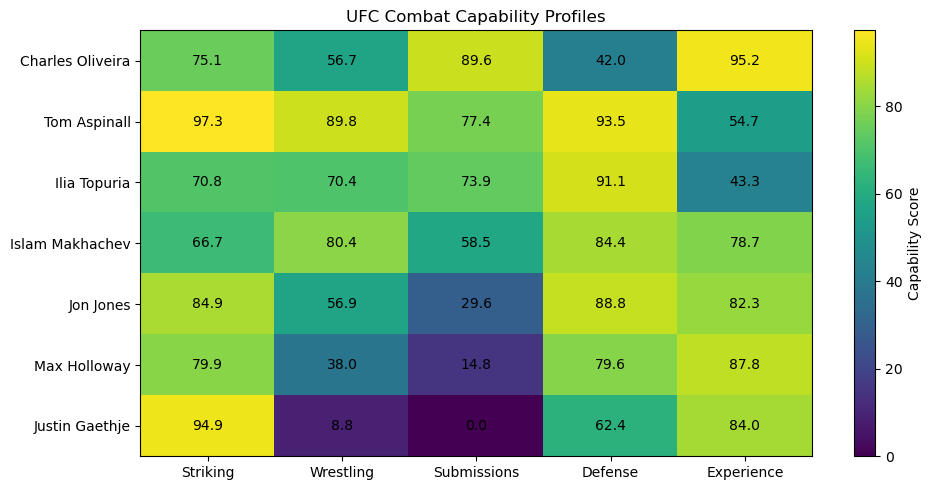

In [73]:
profile_scores = fighter_profiles.set_index("name")[
    [
        "striking_score_100",
        "wrestling_score_100",
        "submissions_score_100",
        "defense_score_100",
        "experience_score_100"
    ]
]

fig, ax = plt.subplots(figsize=(10, 5))

image = ax.imshow(
    profile_scores.values,
    aspect="auto"
)

ax.set_xticks(range(len(profile_scores.columns)))
ax.set_xticklabels(
    ["Striking", "Wrestling", "Submissions", "Defense", "Experience"]
)

ax.set_yticks(range(len(profile_scores.index)))
ax.set_yticklabels(profile_scores.index)

for i in range(len(profile_scores.index)):
    for j in range(len(profile_scores.columns)):
        ax.text(
            j,
            i,
            f"{profile_scores.iloc[i, j]:.1f}",
            ha="center",
            va="center"
        )

plt.colorbar(image, ax=ax, label="Capability Score")
plt.title("UFC Combat Capability Profiles")
plt.tight_layout()
plt.show()

### Comparación directa: Topuria vs Gaethje

El proyecto comenzó comparando las estadísticas de Ilia Topuria y Justin Gaethje, por eso se utiliza este caso para mostrar cómo los capability profiles permiten comparar dos peleadores.

La gráfica no representa una predicción de quién ganaría una pelea. Solamente compara sus posiciones relativas en las cinco dimensiones construidas.

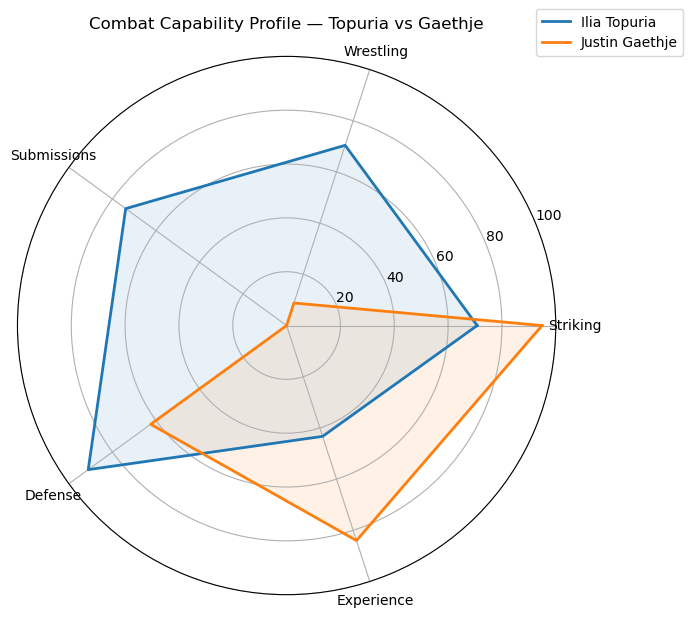

In [74]:
from math import pi

fighters_compare = fighter_profiles[
    fighter_profiles["name"].isin(
        ["Ilia Topuria", "Justin Gaethje"]
    )
].set_index("name")

categories = [
    "Striking",
    "Wrestling",
    "Submissions",
    "Defense",
    "Experience"
]

score_columns = [
    "striking_score_100",
    "wrestling_score_100",
    "submissions_score_100",
    "defense_score_100",
    "experience_score_100"
]

angles = [
    n / len(categories) * 2 * pi
    for n in range(len(categories))
]

angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(7, 7),
    subplot_kw={"polar": True}
)

for fighter in fighters_compare.index:
    values = fighters_compare.loc[
        fighter,
        score_columns
    ].tolist()

    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=fighter
    )

    ax.fill(
        angles,
        values,
        alpha=0.10
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 100)

ax.set_title(
    "Combat Capability Profile — Topuria vs Gaethje",
    pad=20
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.25, 1.10)
)

plt.tight_layout()
plt.show()

# 5. Hallazgos

El análisis permitió encontrar algunas características importantes del dataset y del modelo:

- Las métricas de combate tienen distribuciones muy diferentes. Wrestling y especialmente submissions contienen muchos valores en cero, mientras que las métricas de striking tienen una distribución más continua.

- Min-Max Scaling resultó sensible a algunos valores extremos. El uso de percentile ranks permitió representar mejor la posición relativa de los peleadores sin dejar que unos pocos máximos dominaran la escala.

- El tamaño de muestra sigue siendo importante para interpretar casos individuales, aunque los peleadores con reliability Low o Very Low no aparecen sobrerrepresentados de forma general entre el top 10% de los scores.

- Los scores compuestos fueron bastante estables ante cambios moderados de pesos. Las alternativas 60/40 y 40/60 mantuvieron rankings muy parecidos al baseline 50/50.

- Los perfiles muestran diferencias claras entre peleadores. Por ejemplo, Gaethje presenta un perfil muy alto en Striking pero bajo en las métricas ofensivas de grappling, mientras que Topuria aparece más distribuido entre las dimensiones disponibles.

Estos resultados describen las estadísticas disponibles en el dataset. No deben interpretarse como una medición completa de habilidad ni como una predicción del resultado de una pelea.

# 6. Limitaciones

Esta V1 tiene varias limitaciones que hay que considerar antes de interpretar los scores.

- El dataset no incluye las peleas más recientes, así que algunos records y estadísticas pueden estar desactualizados.

- Los scores representan la posición relativa de cada peleador dentro de este dataset. Un score de 90 no significa tener "90% de habilidad", sino estar muy arriba respecto a los demás registros.

- Las estadísticas disponibles permiten aproximar capacidades, pero no necesariamente estilo de pelea. Un peleador puede tener buenas métricas de wrestling y aun así no utilizarlo como su estrategia principal.

- No se considera la calidad de los rivales. Esto es especialmente importante para Experience, porque tener muchas peleas no dice contra qué nivel de oposición fueron.

- Algunas estadísticas extremas pueden venir de carreras con pocas peleas. No encontramos una sobrerrepresentación general de muestras pequeñas entre los scores más altos, pero siguen siendo casos que requieren cuidado individual.

- Wrestling y Submissions tienen muchos valores en cero. Esto afecta sus distribuciones y hace que no sean directamente comparables con otras dimensiones.

- Los pesos 50/50 son una decisión de baseline. El análisis de sensibilidad mostró que cambios moderados producen rankings bastante similares, pero eso no significa que los pesos sean óptimos.

- No se incluyen atributos físicos como reach, altura, peso o edad. Se dejaron separados de forma intencional para no mezclar características físicas con capacidades técnicas.

- El modelo tampoco considera matchups. Los perfiles describen a cada peleador de forma individual, pero no modelan cómo las fortalezas de uno interactúan con las debilidades de otro.

Por estas razones el Combat Capability Analyzer debe entenderse como una herramienta descriptiva y exploratoria, no como un sistema para determinar quién es el mejor peleador o predecir automáticamente el ganador de una pelea.

# 7. Future Work

Esta V1 funciona como un baseline para describir capacidades de los peleadores. A partir de aquí hay varias mejoras posibles:

- Actualizar el dataset con estadísticas más recientes y eventualmente construir un proceso de actualización de datos.

- Incorporar calidad de oposición para desarrollar una medida de experiencia más completa, no basada solamente en el número de peleas.

- Agregar Physical Attributes como una dimensión separada, utilizando variables como reach, altura, peso y edad.

- Explorar métricas adicionales para representar mejor grappling y submissions. En esta versión Submissions depende solamente de submission attempts per 15 minutes.

- Investigar métodos para ajustar estadísticas con muestras pequeñas, en lugar de utilizar sample reliability solamente como advertencia.

- Trabajar con datos fight-level para separar mejor capability de style. Esto permitiría estudiar no solo qué puede hacer un peleador, sino qué suele elegir hacer durante sus peleas.

- Construir una capa de Matchup Analysis que compare las fortalezas y debilidades de dos peleadores y cómo pueden interactuar entre ellas.

- En una etapa posterior se podría explorar Fight Prediction utilizando datos históricos y validación fuera de muestra.

Los siguientes pasos no buscan reemplazar esta V1, sino construir nuevas capas sobre una base que ya puede ser interpretada y auditada.